# Problem set 6: Solow Model- comments/solutions

# Programming for Economists Summer 2025: Class 9
**Matias BF Hall**

**What you will practice**

* Extending a model you already know: **technology growth** and **population growth**.
* Writing a **class** with a **simulator method**, structured like the one from lecture 9.
* **Testing** new code with `assert` against cases you can already solve.
* Simulating a model where **several parameters are stochastic**.
* Making figures with `fig` and `ax` that are easy to read.

**Answers.** After each question there is a cell like `import A1` + `A1.run()`. Write your own code first, then run the answer cell and compare.

**Table of contents**<a id='toc0_'></a>    
- 1. [The steady state](#toc1_)    
- 2. [The steady-state diagram](#toc2_)    
- 3. [A class with a simulator](#toc3_)    
- 4. [A permanent fall in population growth](#toc4_)    
- 5. [Stochastic saving, technology and population](#toc5_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%load_ext autoreload
%autoreload 2

from types import SimpleNamespace
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size':14})

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# import the solow model from the Python_scripts folder using absolute path
from Python_scripts.solow import SolowModel # the model from lecture 9

In the lecture the number of workers and the level of technology were constant. Now we let both **grow at constant rates**,

$$ A_{t+1} = (1+g)A_t, \qquad L_{t+1} = (1+n)L_t $$

where $A_t$ is technology (how productive a worker is) and $L_t$ is the number of workers. Production now uses both capital and *effective* labour $A_tL_t$,

$$ Y_t = K_t^{\alpha}(A_tL_t)^{1-\alpha}, \qquad K_{t+1} = sY_t + (1-\delta)K_t $$

Because $A_tL_t$ grows, $K_t$ and $Y_t$ keep growing too, and there is no steady state in *levels*. The trick is to measure everything **per effective worker**,

$$ \tilde{k}_t \equiv \frac{K_t}{A_tL_t}, \qquad \tilde{y}_t \equiv \frac{Y_t}{A_tL_t} = \tilde{k}_t^{\alpha} $$

Dividing the capital accumulation equation by $A_{t+1}L_{t+1} = (1+g)(1+n)A_tL_t$ gives the **law of motion**

$$ \tilde{k}_{t+1} = \frac{s f(\tilde{k}_t) + (1-\delta)\tilde{k}_t}{(1+g)(1+n)} $$

and setting $\tilde{k}_{t+1} = \tilde{k}_t = \tilde{k}^{\ast}$ gives the **steady state**

$$ s f(\tilde{k}^{\ast}) = \underbrace{\big[(1+g)(1+n)-(1-\delta)\big]}_{\text{break-even investment}}\tilde{k}^{\ast}
\qquad \Rightarrow \qquad
\tilde{k}^{\ast} = \left(\frac{s}{(1+g)(1+n)-(1-\delta)}\right)^{\frac{1}{1-\alpha}} $$

Investment now has to do more than replace worn-down capital: it also has to equip the new workers and keep up with better technology. For $g = n = 0$ everything collapses back to the model from the lecture.

**The model from the lecture** is in the file [solow.py](solow.py) and was imported above. Use it as a **template** for your own class - and as a **test** of your new formulas.

In [2]:
model_lecture = SolowModel()
print(model_lecture)

Solow model with:
  alpha = 0.33 (capital share)
  s     = 0.20 (savings rate)
  delta = 0.30 (depreciation rate)
  k0    = 0.10 (initial capital per worker)
  T     = 50 (number of periods)


**Parameters used throughout the problem set:**

| parameter | value | meaning |
| --- | --- | --- |
| $\alpha$ | 1/3 | capital share |
| $s$ | 0.20 | savings rate |
| $\delta$ | 0.30 | depreciation rate |
| $g$ | 0.03 | growth rate of technology |
| $n$ | 0.04 | growth rate of the population |

## 1. <a id='toc1_'></a>[The steady state](#toc0_)

**Question:** Write a function `k_star(alpha,s,delta,g,n)` returning the steady-state capital **per effective worker**, and print it for the parameters above.

**Then test it:** with $g = n = 0$ your function must give exactly the same as `SolowModel().steady_state()` from the lecture. Check it with an `assert`, as in section 4.3 of the lecture.

**Hints:**

* The break-even term is `(1+g)*(1+n)-(1-delta)`.
* `SolowModel(alpha=...,s=...,delta=...).steady_state()` returns a tuple `(k,y,c)`, so take element `[0]`.
* `assert np.isclose(a,b), 'a and b are not the same'`

In [3]:
# define parameters to be used in the whole notebook
alpha = 1/3
s = 0.2
delta = 0.30
g = 0.03
n = 0.04
# store parameters in a SimpleNamespace object for easy access
par = SimpleNamespace(alpha=alpha,s=s,delta=delta,g=g,n=n)

# function that returns k* as written above
def k_star(alpha,s,delta,g,n):
    return (s/((1+g)*(1+n)-(1-delta)))**(1/(1-alpha))

# compute different model results
k_star_growth = k_star(alpha,s,delta,g,n)
k_star_no_growth = k_star(alpha,s,delta,0,0)
k_star_no_growth_model = SolowModel().steady_state()[0]

# check that the two k* values without growth are the same
assert np.isclose(k_star_no_growth, k_star_no_growth_model), "The two k* values without growth are not the same"

# print results
for key, value in par.__dict__.items():
    print(f"{key}: {value:.2f}")
print(f"k* with growth: {k_star_growth:.4f}")
print(f"k* without growth: {k_star_no_growth:.4f}")
print(f"k* without growth (model): {k_star_no_growth_model:.4f}")

alpha: 0.33
s: 0.20
delta: 0.30
g: 0.03
n: 0.04
k* with growth: 0.3955
k* without growth: 0.5443
k* without growth (model): 0.5443


## 2. <a id='toc2_'></a>[The steady-state diagram](#toc0_)

**Question:** Make **one figure** with

1. investment per effective worker, $s f(\tilde{k})$,
2. the break-even line **without** growth, $\delta \tilde{k}$,
3. the break-even line **with** growth, $[(1+g)(1+n)-(1-\delta)]\tilde{k}$,

and mark the two steady states. Explain in one sentence why growth in $A$ and $L$ moves the steady state the way it does.

**Hints:**

* Use a grid `k_grid = np.linspace(0,1,500)` and `fig, ax` as in the lecture.
* Mark a steady state with `ax.plot(k,s*k**alpha,'o')` and `ax.axvline(k,ls=':')`.
* Remember a title, axis labels and a legend.

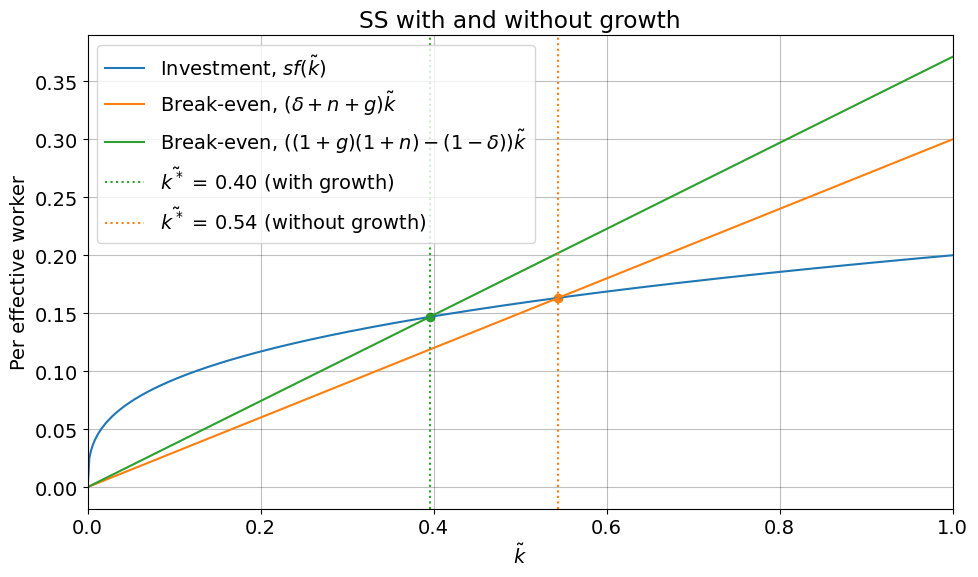

In [4]:
# create grid of k values
k_grid = np.linspace(0, 1, 500)

# compute investment and break-even over grid of k's
investment = s*k_grid**alpha
break_even_no_growth = delta*k_grid
break_even_with_growth = ((1+g)*(1+n)-(1-delta))*k_grid

# plot
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
ax.plot(k_grid, investment, label=r'Investment, $sf(\tilde{k})$', color=colors[0])
ax.plot(k_grid, break_even_no_growth, label=r'Break-even, $(\delta + n + g)\tilde{k}$', color=colors[1])
ax.plot(k_grid, break_even_with_growth, label=r'Break-even, $((1+g)(1+n) - (1-\delta))\tilde{k}$', color=colors[2])
ax.axvline(k_star_growth,ls=':',color=colors[2],label=fr'$\tilde{{k^*}}$ = {k_star_growth:.2f} (with growth)')
ax.axvline(k_star_no_growth,ls=':',color=colors[1],label=fr'$\tilde{{k^*}}$ = {k_star_no_growth:.2f} (without growth)')
ax.scatter(k_star_growth, s*k_star_growth**alpha, color=colors[2])
ax.scatter(k_star_no_growth, s*k_star_no_growth**alpha, color=colors[1])

ax.set_title('SS with and without growth')
ax.xaxis.set_label_text(r'$\tilde{k}$')
ax.yaxis.set_label_text('Per effective worker')
ax.set_xlim(0, 1)
ax.legend()

fig.tight_layout()
plt.show();


## 3. <a id='toc3_'></a>[A class with a simulator](#toc0_)

**Question:** Write a class `SolowModelGrowth` structured exactly like `SolowModel` in [solow.py](solow.py), but with $g$ and $n$ - and with a `simulate` method that keeps track of the **levels** $K_t$, $A_t$, $L_t$, $Y_t$ and $C_t$:

$$ Y_t = K_t^{\alpha}(A_tL_t)^{1-\alpha}, \quad C_t = (1-s_t)Y_t $$
$$ K_{t+1} = s_tY_t + (1-\delta)K_t, \quad A_{t+1} = (1+g_t)A_t, \quad L_{t+1} = (1+n_t)L_t $$

Afterwards it should store both

* **per effective worker:** $\tilde{k}_t = K_t/(A_tL_t)$, $\tilde{y}_t = Y_t/(A_tL_t)$, $\tilde{c}_t = C_t/(A_tL_t)$
* **per worker:** $K_t/L_t$, $Y_t/L_t$, $C_t/L_t$

in `self.sim`. Let `s`, `g` and `n` be either a **number** (constant) or an **array** with one value per period - you will need that in question 6.

**Then test it** with `assert`, as in section 4.3 of the lecture. Good tests here are:

1. an economy that **starts** in the steady state must **stay** there,
2. with $g = n = 0$ your class must reproduce the model from the lecture **period by period**,
3. the population must grow at exactly the rate $n$.

**Then use it:** simulate from a low starting point and make a figure with two panels:

1. capital per effective worker $\tilde{k}_t$, with a line at the steady state $\tilde{k}^{\ast}$,
2. the **growth rate** of output per worker, `sim.y_pw[1:]/sim.y_pw[:-1]-1`, with a line at $g$.

What is the growth rate of output per worker in the long run?

**Hints:**

* Only the levels need a loop. All the per-worker variables can be computed *after* the loop with array division, e.g. `self.sim.k = K/(A*L)`.
* Copy the trick from the lecture for handling a number or an array:
  `np.full(T,x) if np.ndim(x) == 0 else np.asarray(x,dtype=float)`.

Use the skeleton below as a starting point.

In [5]:
# I use the SolowModel as a parent class and inherit all its methods and attributes, then I can add new methods and attributes to the child class
class SolowModelGrowth(SolowModel):
    """ the Solow model with technology growth and population growth """

    def __init__(self,**kwargs): # we use **kwargs to allow for any number of keyword arguments to be passed to the constructor, this way we can easily overwrite any default parameters without having to specify all of them every time we create a new instance of the class
        #SolowModel.__init__(self,**kwargs) # we want to inherit all the parameters from the SolowModel class, and add some attributes in the init method
        super().__init__(**kwargs) # since we want to inherit both attributes and methods from the SolowModel class, we use super() instead. We ovewride some methods below
        """ set the default parameters, then overwrite with any keyword arguments """

        # a. new parameters
        self.g = 0.03 # growth rate of technology
        self.n = 0.04 # growth rate of the population

        # b. new simulation settings
        self.K0 = 0.05 # initial capital
        self.A0 = 1.00 # initial technology
        self.L0 = 1.00 # initial population
        self.T = 100 # number of periods, we override the T from the parent class

        # c. overwrite with keyword arguments
        # we overwrite the default parameters with any keyword arguments passed to the constructor so we don't need to specify all parameters every time we create a new instance of the class
        for key,value in kwargs.items():
            setattr(self,key,value)

        # d. empty container for simulation results
        self.sim = SimpleNamespace()

    # below I have removed functions that are already implemented in the parent class, and I will only implement the new/changed functions that are specific to the SolowModelGrowth class

    def steady_state(self):
        """ analytical steady state per effective worker, returns (k,y,c) """

        k = (self.s/((1+self.g)*(1+self.n)-(1-self.delta)))**(1/(1-self.alpha))
        y = self.f(k)
        c = (1-self.s)*y

        return k,y,c

    def simulate(self,s=None,g=None,n=None):
        """ simulate the model forward in time, results are stored in self.sim """

        # a. settings
        if s is None: s = self.s
        if g is None: g = self.g
        if n is None: n = self.n
        # we have parameters as arguments so we can change them if we want, if not we use the default values

        # b. savings rate in each period (np.ndim(s) == 0 means s is a single number)
        # this allows for the savings rate to change over time, if we have parameters be arrays
        s_vec = np.full(self.T,s) if np.ndim(s) == 0 else np.asarray(s,dtype=float)
        g_vec = np.full(self.T,g) if np.ndim(g) == 0 else np.asarray(g,dtype=float)
        n_vec = np.full(self.T,n) if np.ndim(n) == 0 else np.asarray(n,dtype=float)
        assert (s_vec.size == self.T) and (g_vec.size == self.T) and (n_vec.size == self.T), f'the parameters (s, g, n) must have {self.T} elements, but have {s_vec.size}, {g_vec.size}, and {n_vec.size} respectively'

        # c. allocate memory
        K = np.empty(self.T) # capital
        A = np.empty(self.T) # technology
        L = np.empty(self.T) # workers
        Y = np.empty(self.T) # output
        C = np.empty(self.T) # consumption

        # d. initial values
        K[0] = self.K0
        A[0] = self.A0
        L[0] = self.L0

        # e. loop forward in time
        for t in range(self.T):

            # compute curent period values
            Y[t] = K[t]**self.alpha*(A[t]*L[t])**(1-self.alpha) # production
            C[t] = (1-s_vec[t])*Y[t] # consumption

            # compute next period values
            if t < self.T-1: # the law of motion for technology, workers, and capital
                A[t+1] = (1+g_vec[t])*A[t]
                L[t+1] = (1+n_vec[t])*L[t]
                K[t+1] = s_vec[t]*Y[t] + (1-self.delta)*K[t]

        # f. store the results
        # direct values from the simulation
        self.sim.K = K
        self.sim.A = A
        self.sim.L = L
        self.sim.Y = Y
        self.sim.C = C
        self.sim.s = s_vec
        self.sim.g = g_vec
        self.sim.n = n_vec
        # derived values from the simulation
        self.sim.k = K/(A*L) # capital per effective worker
        self.sim.y = Y/(A*L) # output per effective worker
        self.sim.c = C/(A*L) # consumption per effective worker
        self.sim.k_per_worker = K/L # capital per worker
        self.sim.y_per_worker = Y/L # output per worker
        self.sim.c_per_worker = C/L # consumption per worker

        return self.sim

In [6]:
### TESTING ###

# create two instances of the SolowModelGrowth class for testing
model_growth_test = SolowModelGrowth()
model_no_growth_test = SolowModelGrowth(g=0,n=0)

#simulate test models to get simulation results
test_growth_sim = model_growth_test.simulate()
test_no_growth_sim = model_no_growth_test.simulate()

# test model using examples given by Jeppe

# 1. "an economy that starts in the steady state must stay there"
# assert that the simulation stays in the steady state after reaching it
assert np.allclose(test_growth_sim.k[50:], k_star_growth), "Simulation does not stay in SS after reaching it"
# 2. "with g=0 and n=0 your class must reproduce the model from the lecture period by period"
# get capital per worker from the growth model(without growth) and use it as initial value for the lecture model sim
capital_per_worker_guess = model_no_growth_test.K0/model_no_growth_test.L0
lecture_sim = model_lecture.simulate(k0=capital_per_worker_guess, T=model_no_growth_test.T)
# simulate the growth model with g=0 and n=0
test_no_growth_sim = model_no_growth_test.simulate()
# assert that the simulation with g=0 and n=0 reproduces the model from the lecture period by period
assert np.allclose(test_no_growth_sim.k_per_worker, lecture_sim.k), "Simulation with g=0 and n=0 does not reproduce the model from the lecture period by period"
# 3. "the population must grow at exactly the rate, n"
# assert that the simulation reproduces the population growth at the expected rate
assert np.allclose(test_growth_sim.L, model_growth_test.L0 * (1 + model_growth_test.n) ** np.arange(model_growth_test.T)), "Population does not grow at the expected rate"

# all tests passed so now we can move on the the next part

Theoretical steady state k*: 0.3955, last period k: 0.3955
Theoretical steady state y*: 0.7340, last period y: 0.7340


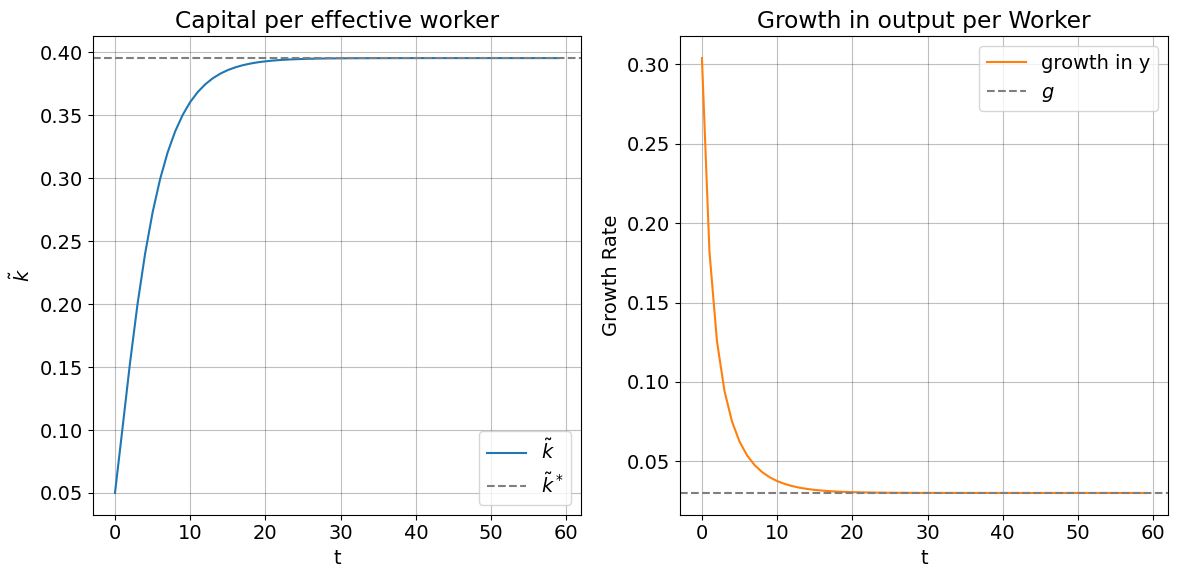

In [7]:
# create instance of the SolowModelGrowth class with default parameters to simulate the model and plot the results
model_growth = SolowModelGrowth()

# compute theoretical steady state and simulate the model and get last period values of k and y to compare
k_star_ss, y_star_ss = model_growth.steady_state()[0:2]
simulation_results = model_growth.simulate()
k_last = simulation_results.k[-1]
y_last = simulation_results.y[-1]
# print results
print(f"Theoretical steady state k*: {k_star_ss:.4f}, last period k: {k_last:.4f}")
print(f"Theoretical steady state y*: {y_star_ss:.4f}, last period y: {y_last:.4f}")

# compute growth in output per worker in each period of the simulation
growth_y_per_worker = np.diff(simulation_results.y_per_worker)/simulation_results.y_per_worker[:-1]

# plot the results of the simulation
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(simulation_results.k[:-40], label=r'$\tilde{k}$', color=colors[0])
axs[0].axhline(k_star_ss, ls='--', color=colors[7], label=r'$\tilde{k}^*$')
axs[0].set_title('Capital per effective worker')
axs[0].set_xlabel('t')
axs[0].set_ylabel(r'$\tilde{k}$')
axs[0].legend()

axs[1].plot(growth_y_per_worker[:-39], label='growth in y', color=colors[1])
axs[1].axhline(model_growth.g, ls='--', color=colors[7], label=r'$g$')
axs[1].set_title('Growth in output per Worker')
axs[1].set_xlabel('t')
axs[1].set_ylabel('Growth Rate')
axs[1].legend()

fig.tight_layout()
plt.show();

## 4. <a id='toc4_'></a>[A permanent fall in population growth](#toc0_)

Population growth is falling in most rich countries. What does that do to the economy?

**Question:** Let the economy **start in its steady state** and let population growth fall permanently from $n = 0.04$ to $n = 0.02$ in period $t_{\text{switch}} = 30$. Compare with a baseline where $n$ stays at $0.04$.

Make a figure with two panels:

1. capital per effective worker in the two scenarios, with lines at the old and the new steady state,
2. the growth rate of output per worker in the two scenarios, with a line at $g$.

Is the effect on growth **permanent** or **temporary**? What about the effect on the *level* of output per worker?

**Hints:**

* Build the path with `n_path = np.full(T,0.04)` and `n_path[t_switch:] = 0.02`, then call `simulate(n=n_path)`.
* To start in the steady state, set `K0` such that $K_0/(A_0L_0) = \tilde{k}^{\ast}$.
* Mark the switch with `ax.axvline(t_switch,lw=6,color='black',alpha=0.15,zorder=0)`.

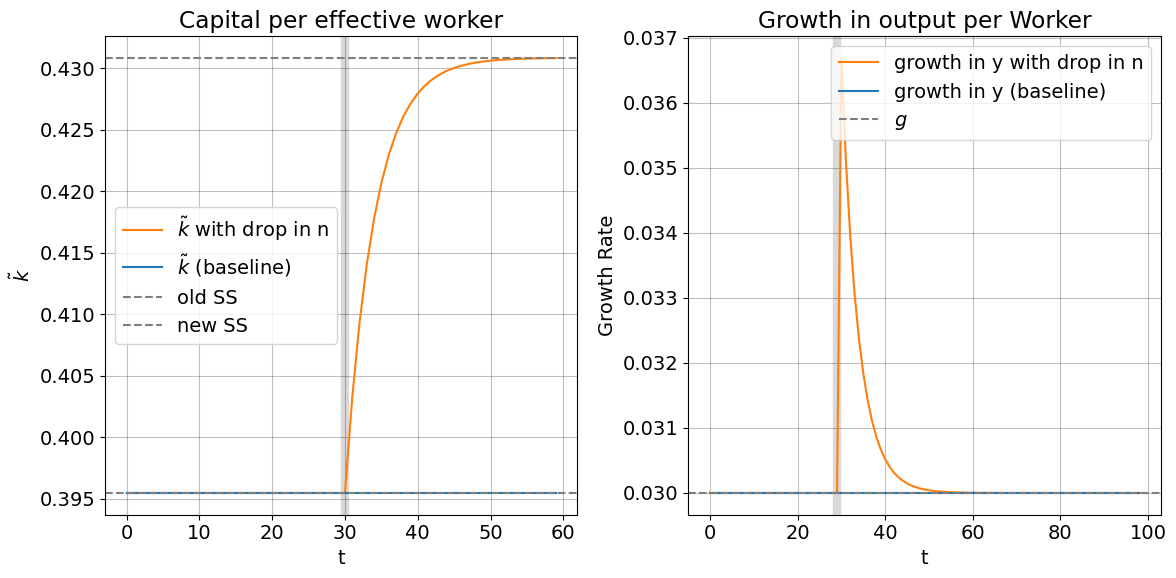

In [8]:
# create new instance of the SolowModelGrowth so we don't overwrite the previous simulation results
model_growth_pop = SolowModelGrowth()

# create path for n
t_switch = 30
n_path = np.full(model_growth_pop.T, 0.04)
n_path[t_switch:] = 0.02 # change n after t_switch periods

# set K0 so that the economy starts in the steady state with n=0.04
K0_SS = model_growth_pop.steady_state()[0]*model_growth_pop.A0*model_growth_pop.L0
model_growth_pop.K0 = K0_SS

# create a baseline model to simulate the baseline scenario for comparison
model_growth_baseline = SolowModelGrowth(K0=K0_SS)

# simulate the model with the new path for n and baseline simulation for comparison
simulation_results_pop = model_growth_pop.simulate(n=n_path)
simulation_results_baseline = model_growth_baseline.simulate()

# get steadty state values for the two different n's
k_star_baseline, y_star_baseline = model_growth_pop.steady_state()[0:2]
model_growth_pop.n = 0.02 # change n to the new value to compute the new steady state
k_star_low_n, y_star_low_n = model_growth_pop.steady_state()[0:2]

# compute growth in output per worker in each period of the simulation
growth_y_per_worker_n = np.diff(simulation_results_pop.y_per_worker)/simulation_results_pop.y_per_worker[:-1]
growth_y_per_worker_baseline = np.diff(simulation_results_baseline.y_per_worker)/simulation_results_baseline.y_per_worker[:-1]

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(simulation_results_pop.k[:-40], label=r'$\tilde{k}$ with drop in n', color=colors[1]) # plot the capital per effective worker for the simulation with the drop in n
axs[0].plot(simulation_results_baseline.k[:-40], label=r'$\tilde{k}$ (baseline)', color=colors[0]) # plot the capital per effective worker for the baseline simulation
axs[0].axhline(k_star_baseline, ls='--', color=colors[7], label=f'old SS') # mark the SS in the baseline
axs[0].axhline(k_star_low_n, ls='--', color=colors[7], label=f'new SS') # mark the SS after a drop in n
axs[0].axvline(t_switch,lw=6,color='black',alpha=0.15,zorder=0) # mark the time of the drop in n
axs[0].set_title('Capital per effective worker')
axs[0].set_xlabel('t')
axs[0].set_ylabel(r'$\tilde{k}$')
axs[0].legend()

axs[1].plot(growth_y_per_worker_n, label='growth in y with drop in n', color=colors[1]) # plot the growth in output per worker for the simulation with the drop in n
axs[1].plot(growth_y_per_worker_baseline, label='growth in y (baseline)', color=colors[0]) # plot the growth in output per worker for the baseline simulation
axs[1].axhline(model_growth.g, ls='--', color=colors[7], label=r'$g$') # mark the growth rate of technology
axs[1].axvline(t_switch-1,lw=6,color='black',alpha=0.15,zorder=0) # mark the time of the drop in n, minus 1 because the growth rate is computed as the difference between periods
axs[1].set_title('Growth in output per Worker')
axs[1].set_xlabel('t')
axs[1].set_ylabel('Growth Rate')
axs[1].legend()

fig.tight_layout()
plt.show();

## 5. <a id='toc5_'></a>[Stochastic saving, technology and population](#toc0_)

In the lecture only the savings rate was stochastic. Now **all three** of $s_t$, $g_t$ and $n_t$ fluctuate, each as an AR(1) process,

$$ x_t = (1-\rho)\bar{x} + \rho x_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\sigma^2) $$

For the savings rate, run the process **in logs** (as in the lecture) so that $s_t$ is always positive. For $g_t$ and $n_t$ the level is fine - they are allowed to be negative.

**Question:**

1. Write a function `draw_ar1(rng,T,mean,rho,sigma)` returning one AR(1) path, and a function that uses it to draw the three paths $s_t$, $g_t$ and $n_t$.
2. Simulate `N = 500` economies, each with its own draws, starting from the deterministic steady state. Store $\tilde{k}_t$ for all of them in an array with shape `(N,T)`.
3. For each economy compute the **average growth rate** of output per worker over the whole simulation, `(y_pw[-1]/y_pw[0])**(1/(T-1))-1`.
4. Make a figure with two panels: a **fan chart** of $\tilde{k}_t$ (median and the 10th-90th percentile band across economies) and a **histogram** of the average growth rates. Mark the deterministic values in both panels.

Are the economies more spread out in the *level* of capital or in their *long-run growth rate*? Why?

**Hints:**

* Suggested sizes of the shocks: $\rho = 0.90$, $\sigma_s = 0.07$, $\sigma_g = \sigma_n = 0.005$.
* Use one generator `rng = np.random.default_rng(2026)` for all the draws.
* Percentiles across economies: `np.percentile(k_all,10,axis=0)`.
* A band is drawn with `ax.fill_between(np.arange(T),k_low,k_high,alpha=0.30)`.
* Remember to **copy** the result out of `sim` inside the loop - the next call overwrites it.

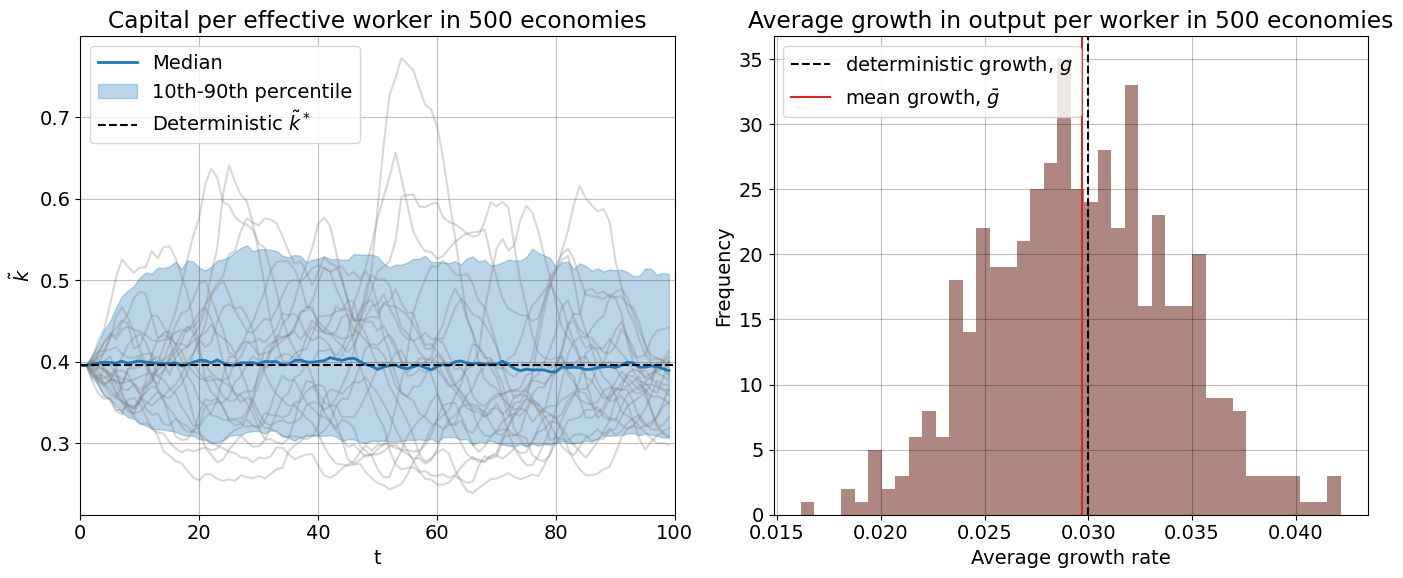

In [9]:
# create function to draw the ar1 paths
def draw_ar1(rng,T,mean,rho,sigma):

    # draw all shocks
    eps = rng.normal(0,sigma,size=T)

    # create container for the ar1 process and start off in the long run SS
    x = np.empty(T)
    x[0] = mean
    # create the recursive process with the formula above
    for t in range(1,T):
        x[t] = (1-rho)*mean + rho*x[t-1] + eps[t]
    return x

# create function that uses the ar1 process to draw s, g and n
def draw_rate_paths(rng,T,model,rho=0.9,sigma_s=0.07,sigma_g=0.005,sigma_n=0.005):

    # draw the paths
    s_path = np.exp(draw_ar1(rng,T,np.log(model.s),rho,sigma_s)) # savings rate is drawn in logs to ensure it stays positive
    g_path = draw_ar1(rng,T,model.g,rho,sigma_g)
    n_path = draw_ar1(rng,T,model.n,rho,sigma_n)

    return s_path,g_path,n_path

# set number of economies and periods to simulate
N = 500
T = 100

# create containers for the simulation results we want to store
k_all = np.empty((N,T))
y_pw_all = np.empty((N,T))
y_pw_growthrate_all = np.empty(N) # we will compute the growth rate of output per worker over the whole period for each economy, so we only need to store one value per economy

# set random number generator for reproducibility
rng = np.random.default_rng(seed=2026)
# create instance of the SolowModelGrowth class in SS to simulate the model
model_growth_stochastic = SolowModelGrowth(K0=K0_SS, T=T)

# simulate N economies with stochastic paths for s, g and n
for i in range(N):
    # draw stochastic paths for s, g and n
    s_path,g_path,n_path = draw_rate_paths(rng,T,model_growth_stochastic)

    # simulate the model with the drawn paths
    sim_results = model_growth_stochastic.simulate(s=s_path,g=g_path,n=n_path)

    # store the results we want to analyze
    k_all[i,:] = sim_results.k
    y_pw_all[i,:] = sim_results.y_per_worker
    y_pw_growthrate_all[i] = (y_pw_all[i,-1] / y_pw_all[i,0])**(1/(T-1)) - 1

# compute percentiles
k_median = np.median(k_all, axis=0)
k_10th = np.percentile(k_all, 10, axis=0)   
k_90th = np.percentile(k_all, 90, axis=0)

# plot, I use a lot of the same formatting as the answers
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].plot(k_all[:20,:].T, color=colors[7], alpha=0.3) # plot the first 20 economies to visualize the stochastic paths of the capital per effective worker across all economies. We transpose to get the time on the x-axis and the capital per effective worker on the y-axis
axs[0].plot(k_median, label='Median', color=colors[0],lw=2) # plot the median of the capital per effective worker across all economies
axs[0].fill_between(np.arange(T), k_10th, k_90th, color=colors[0], alpha=0.3, label='10th-90th percentile') # colour in the 10th to 90th percentile range of the capital per effective worker across all economies
axs[0].axhline(k_star_baseline, ls='--', color='black', label=r'Deterministic $\tilde{k}^*$') # mark the theoretical steady state of the capital per effective worker
axs[0].set_title(f'Capital per effective worker in {N} economies')
axs[0].set_xlabel('t')
axs[0].set_ylabel(r'$\tilde{k}$')
axs[0].set_xlim(0, 100)
axs[0].legend()

axs[1].hist(y_pw_growthrate_all, bins=40, color=colors[5], alpha=0.7) # plot the histogram of the growth rates of output per worker across all economies
axs[1].axvline(model_growth.g, ls='--', color='black', label=r'deterministic growth, $g$') # mark the growth rate of technology
axs[1].axvline(np.mean(y_pw_growthrate_all), color=colors[3], label=r'mean growth, $\bar{g}$') # mark the mean growth rate of output per worker across all economies

axs[1].set_title(f'Average growth in output per worker in {N} economies')
axs[1].set_xlabel('Average growth rate')
axs[1].set_ylabel('Frequency')
axs[1].legend()

fig.tight_layout()
plt.show();
